In [1]:
import scanpy as sc
import numpy as np
import anndata as ad
import pandas as pd
from pathlib import Path
import pickle
import os
import pycisTopic
pycisTopic.__version__

'2.0a0'

In [1]:
import pycistarget

/jukebox/scratch/vn0027/envs/scenicplus/lib/python3.11/site-packages/pycistarget/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [2]:
pycistarget.__version__

'1.1'

In [2]:
os.chdir("/jukebox/krienen/victor/marm_hmba_atac_50k/")

In [3]:
with open("/jukebox/krienen/victor/marm_hmba_atac_50k/data/cistopic_obj_nonneuron_geosketch_50kcells_marm_subcortex.pkl", "rb") as fp:
    cistopic_obj = pickle.load(fp)

# Evaluate models
models = []
model_dir = "/jukebox/krienen/victor/marm_hmba_atac_50k/pycisTopic/nonneuron/outs/models/"

for file in os.listdir(model_dir):
    # Check whether file is a result from topic modelling, e.g. based on the name
    if file.endswith(".pkl"):
        file_path = os.path.join(model_dir, file)
        with open(file_path, "rb") as f:
            model = pickle.load(f)
        models.append(model)


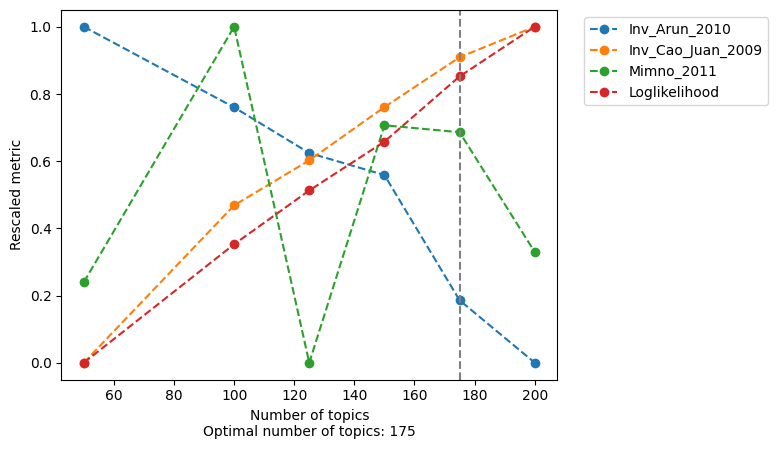

In [5]:
from pycisTopic.lda_models import evaluate_models
model = evaluate_models(
    models,
    select_model = 175,
    return_model = True
    #metrics = ["Minmo_2011", "loglikelihood", "Cao_Juan_2009", "Arun_2010"]
)

In [6]:
cistopic_obj.add_LDA_model(model)

In [7]:
# Identify cell-topic clusters
from pycisTopic.clust_vis import (
    find_clusters,
    run_umap,
    run_tsne,
    plot_metadata,
    plot_topic,
    cell_topic_heatmap
)

find_clusters(
    cistopic_obj,
    target  = 'cell',
    k = 10,
    res = [0.6, 1.2, 3],
    prefix = 'pycisTopic_',
    scale = True,
    split_pattern = '___'
)

run_umap(
    cistopic_obj,
    target  = 'cell', scale=True)

run_tsne(
    cistopic_obj,
    target  = 'cell', scale=True)

2025-08-13 10:25:31,963 cisTopic     INFO     Finding neighbours
2025-08-13 10:25:54,826 cisTopic     INFO     Running UMAP


/jukebox/scratch/vn0027/envs/scenicplus/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


2025-08-13 10:26:59,482 cisTopic     INFO     Running TSNE


In [8]:
# Add metadata to a cistopic object
adata_rna = sc.read_h5ad("/jukebox/krienen/victor/marm_hmba_atac_50k/data/rna_nonneuron_geosketch_50kcells_marm_subcortex.h5ad", backed='r')
metadata_rna = adata_rna.obs[['Subcortex_Class_v4', 'Subcortex_Group_v4']].copy()

# Add metadata to a cistopic object
adata_atac = sc.read_h5ad("/jukebox/krienen/victor/marm_hmba_atac_50k/data/atac_nonneuron_geosketch_50kcells_marm_subcortex.h5ad", backed='r')
metadata_atac = adata_atac.obs[['tsse', 'n_fragment']].copy()

cistopic_obj.add_cell_data(metadata_rna, split_pattern='___')
cistopic_obj.add_cell_data(metadata_atac, split_pattern='___')

cistopic_obj.cell_data["FRiP"] = (
    cistopic_obj.cell_data["cisTopic_nr_frag"]  # fragments that fall into consensus peaks
    / cistopic_obj.cell_data["n_fragment"]      # total fragments for the barcode
)
cistopic_obj.cell_data

,cisTopic_nr_frag,cisTopic_log_nr_frag,cisTopic_nr_acc,cisTopic_log_nr_acc,sample_id,pycisTopic_leiden_10_0.6,pycisTopic_leiden_10_1.2,pycisTopic_leiden_10_3,Subcortex_Class_v4,Subcortex_Group_v4,tsse,n_fragment,FRiP
AATGTCATCATGTCAA-P0005_2___cisTopic,6017,3.77938,3388,3.529943,cisTopic,0,2,6,Nonneuron,Oligo OPALIN,12.701174,6272,0.959343
AGCGGATAGCTTAACA-P0005_2___cisTopic,105402,5.022849,36794,4.565777,cisTopic,3,2,10,Nonneuron,ImOligo,18.470614,104441,1.009201
GAGGTGAGTTGTTCAC-P0005_2___cisTopic,103636,5.015511,38679,4.587475,cisTopic,8,12,13,Nonneuron,ImOligo,16.093527,112128,0.924265
ATCATGTCAGCCTGCA-P0005_2___cisTopic,46871,4.670904,21798,4.338417,cisTopic,3,1,10,Nonneuron,Oligo OPALIN,13.845775,57534,0.814666
GGGATAATCTGGCATG-P0005_2___cisTopic,1453,3.162266,875,2.942008,cisTopic,0,2,27,Nonneuron,Oligo OPALIN,8.264463,1642,0.884896
...,...,...,...,...,...,...,...,...,...,...,...,...,...
GCGCTAGGTAAGTCGC-P0081_2___cisTopic,4501,3.653309,2557,3.407731,cisTopic,7,10,12,Nonneuron,Microglia,11.754757,5844,0.770192
TGCTCTCAGCTTTGGG-P0081_2___cisTopic,13891,4.142734,6532,3.815046,cisTopic,0,8,6,Nonneuron,Oligo OPALIN,17.482517,12334,1.126236
TGAGCCGGTGCATTTC-P0081_2___cisTopic,23077,4.363179,10809,4.033786,cisTopic,7,10,12,Nonneuron,Microglia,13.411138,27188,0.848794
GTTTAGCAGTTGGATC-P0081_2___cisTopic,2304,3.362482,1307,3.116276,cisTopic,2,4,20,Nonneuron,Microglia,15.656566,2521,0.913923


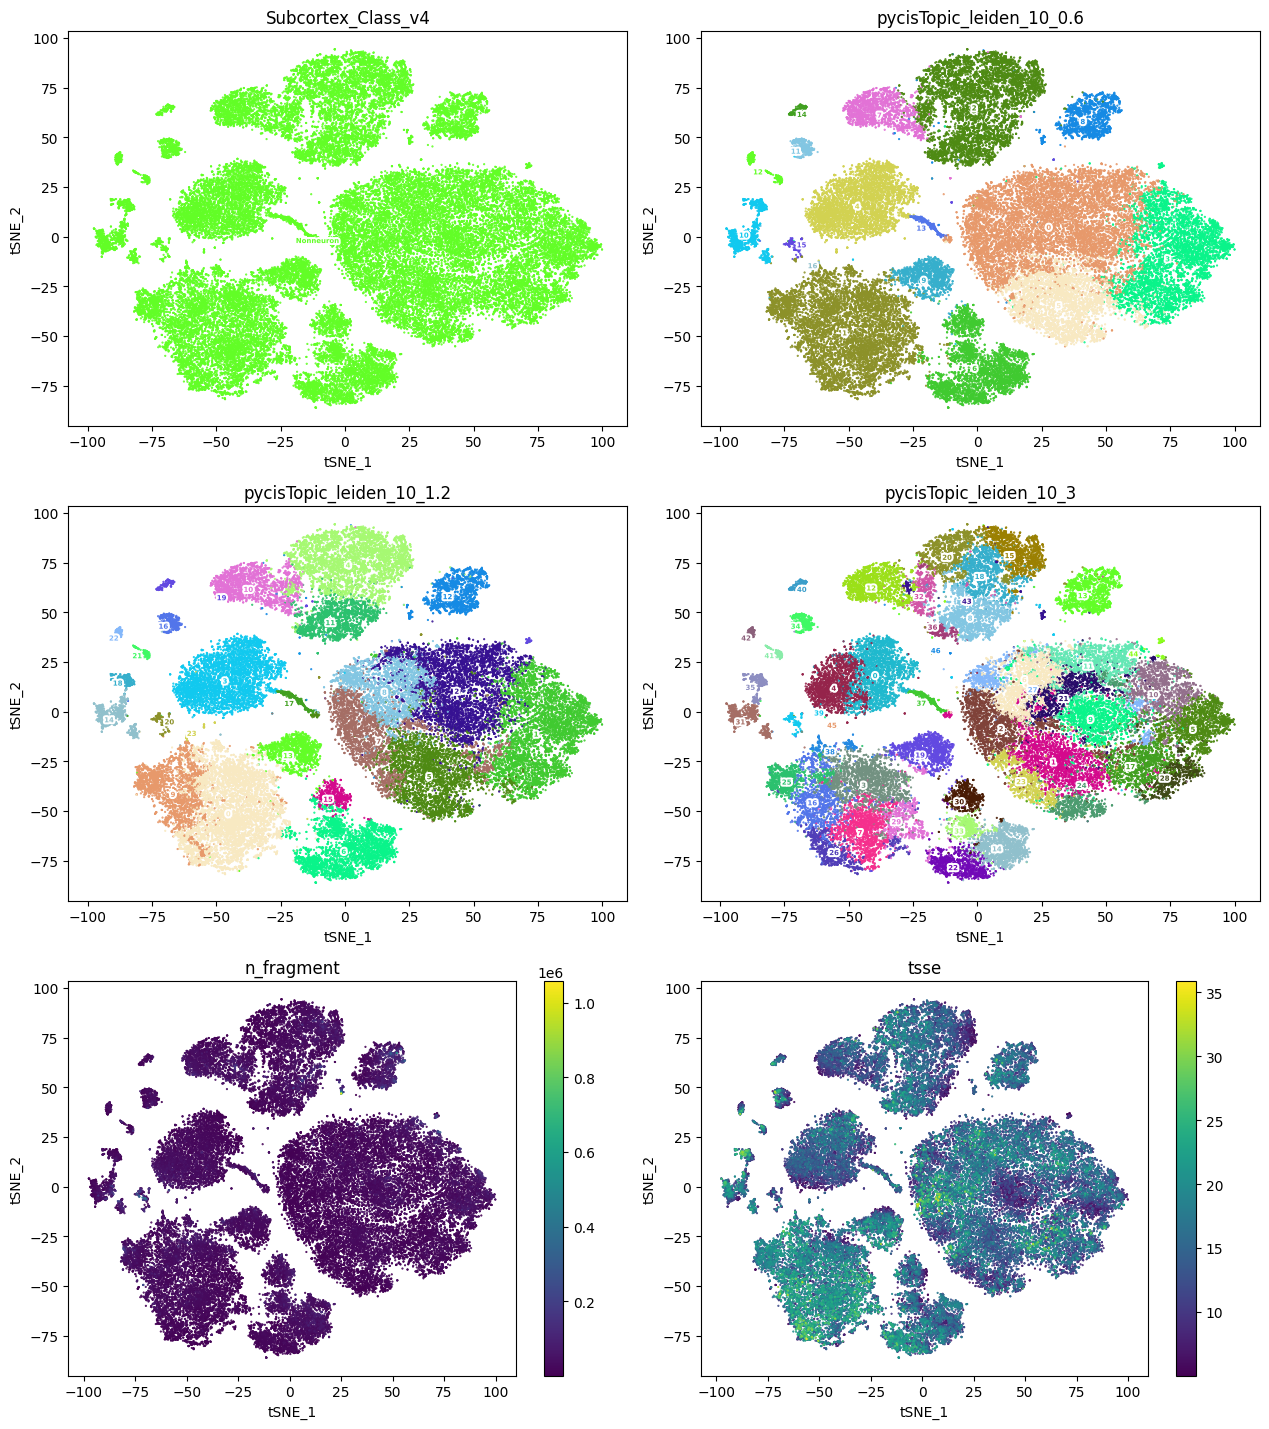

In [9]:
plot_metadata(
    cistopic_obj,
    reduction_name='tSNE',
    variables=['Subcortex_Class_v4', 'pycisTopic_leiden_10_0.6', 'pycisTopic_leiden_10_1.2','pycisTopic_leiden_10_3','n_fragment', 'tsse'],
    target='cell',num_columns=2,
    show_legend= False,
    show_label= True, 
    text_size=5,
    dot_size=0.3,
)

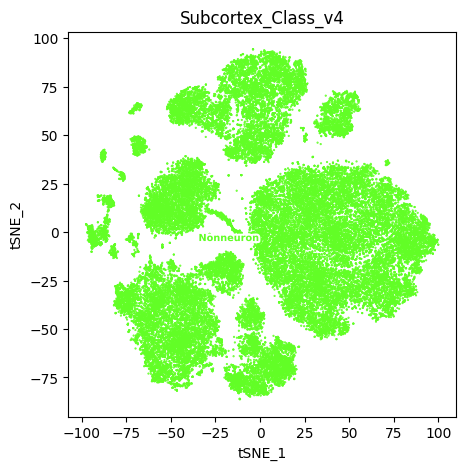

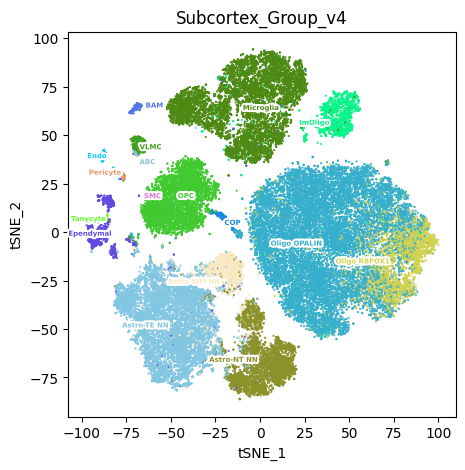

In [10]:
# Create a dir to store the output of pycisTopic
out_dir = "plots"
os.makedirs(out_dir, exist_ok = True)

plot_metadata(
    cistopic_obj,
    reduction_name='tSNE',
    variables=['Subcortex_Class_v4'],
    target='cell',
    show_legend= False,
    show_label= True, 
    text_size=7,
    dot_size=0.3,
    figsize=(5, 5),
    save="./plots/tSNE_175topics_Class_downsample_geosketch_50kcells_nonneuron.pdf" 
)

plot_metadata(
    cistopic_obj,
    reduction_name='tSNE',
    variables=['Subcortex_Group_v4'],
    target='cell',
    show_legend= False,
    show_label= True, 
    text_size=5,
    dot_size=0.3,
    figsize=(5, 5),
    save="./plots/tSNE_175topics_Group_downsample_geosketch_50kcells_nonneuron.pdf" 
)

In [11]:
# Update cistopicsobject with model 
out_cistopic_path = "/jukebox/krienen/victor/marm_hmba_atac_50k/data/cistopic_obj_nonneuron_geosketch_50kcells_marm_subcortex.pkl"
with open(out_cistopic_path, "wb") as fh:
    pickle.dump(cistopic_obj, fh)

In [12]:
with open("/jukebox/krienen/victor/marm_hmba_atac_50k/data/cistopic_obj_neuron_geosketch_50kcells_marm_subcortex.pkl", "rb") as fp:
    cistopic_obj = pickle.load(fp)
cistopic_obj.cell_data


AttributeError: 'CistopicObject' object has no attribute 'model'

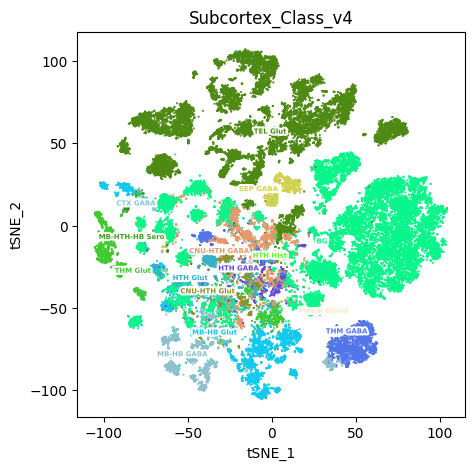

In [15]:
plot_metadata(
    cistopic_obj,
    reduction_name='tSNE',
    variables=['Subcortex_Class_v4'],
    target='cell',
    show_legend= False,
    show_label= True, 
    text_size=5,
    dot_size=0.3,
    figsize=(5, 5),
)

In [16]:
cistopic_obj.region_names

['chr1:135544-136045',
 'chr1:167473-167974',
 'chr1:262780-263281',
 'chr1:287239-287740',
 'chr1:289894-290395',
 'chr1:398174-398675',
 'chr1:404711-405212',
 'chr1:438813-439314',
 'chr1:449476-449977',
 'chr1:501794-502295',
 'chr1:512360-512861',
 'chr1:534047-534548',
 'chr1:553812-554313',
 'chr1:554363-554864',
 'chr1:553177-553678',
 'chr1:591609-592110',
 'chr1:596776-597277',
 'chr1:625002-625503',
 'chr1:638383-638884',
 'chr1:645675-646176',
 'chr1:650327-650828',
 'chr1:663467-663968',
 'chr1:686781-687282',
 'chr1:708156-708657',
 'chr1:727123-727624',
 'chr1:726260-726761',
 'chr1:761533-762034',
 'chr1:762446-762947',
 'chr1:772503-773004',
 'chr1:806708-807209',
 'chr1:811843-812344',
 'chr1:835626-836127',
 'chr1:845726-846227',
 'chr1:851285-851786',
 'chr1:850663-851164',
 'chr1:859433-859934',
 'chr1:862459-862960',
 'chr1:890036-890537',
 'chr1:890769-891270',
 'chr1:901541-902042',
 'chr1:907774-908275',
 'chr1:916447-916948',
 'chr1:935719-936220',
 'chr1:9423

In [17]:
!pwd

/mnt/cup/labs/krienen/victor/marm_hmba_atac_50k


In [18]:
with open("/jukebox/krienen/victor/marm_hmba_atac_50k/data/marm_subcortex_filtered_peaks.txt", "w") as f:
    for region in cistopic_obj.region_names:
        f.write(region + "\n")

#awk -F '[:-]' '{print $1 "\t" $2 "\t" $3}' /jukebox/krienen/victor/marm_hmba_atac_50k/data/marm_subcortex_filtered_peaks.txt > /jukebox/krienen/victor/marm_hmba_atac_50k/data/marm_subcortex_filtered_peaks.bed

In [8]:
'''# names you want to exclude
exclude_groups = ["Nonneuron", "Junk"]

# get cell barcodes we want to keep
keep_cells = (
    cistopic_obj.cell_data
    .query("Subcortex_Group_v4 not in @exclude_groups ")      # fast, readable
    .index
)

# subset the whole object in one call
cistopic_obj = cistopic_obj.subset(cells=keep_cells) '''
cistopic_obj.cell_data['Subcortex_Class_v4'] = cistopic_obj.cell_data['Subcortex_Class_v4'].astype(str)

In [ ]:
'''exclude = {'nan'}
clean_group_labels = [
    v for v in cistopic_obj.cell_data['Subcortex_Class_v4'].dropna().unique()
    if v not in exclude
]
clean_group_labels'''

cell_topic_heatmap(
    cistopic_obj,
    variables = ['Subcortex_Class_v4'],
    scale = True,
    legend_loc_x = 1.0,
    legend_loc_y = -1.2,
    legend_dist_y = -1,
    figsize = (10, 10),
    save="./plots/cell_topic_heatmap_200topics_Class_downsample_geosketch_50kcells_neuron.pdf" 
)

In [9]:
cistopic_obj.cell_data['Subcortex_Group_v4'] = cistopic_obj.cell_data['Subcortex_Group_v4'].astype(str)

In [ ]:
cell_topic_heatmap(
    cistopic_obj,
    variables = ['Subcortex_Group_v4'],
    scale = True,
    legend_loc_x = 1.0,
    legend_loc_y = -1.2,
    legend_dist_y = -1,
    figsize = (10, 10),
    save="./plots/cell_topic_heatmap_200topics_Group_downsample_geosketch_50kcells_neuron.pdf" 
)

In [10]:
from pycisTopic.topic_binarization import binarize_topics

region_bin_topics_top_3k = binarize_topics(
    cistopic_obj, method='ntop', ntop = 3_000,
    plot=False
)

binarized_cell_topic = binarize_topics(
    cistopic_obj,
    target='cell',
    method='li',
    plot=False
)

from pycisTopic.topic_qc import compute_topic_metrics, plot_topic_qc, topic_annotation
import matplotlib.pyplot as plt
from pycisTopic.utils import fig2img

topic_qc_metrics = compute_topic_metrics(cistopic_obj)

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

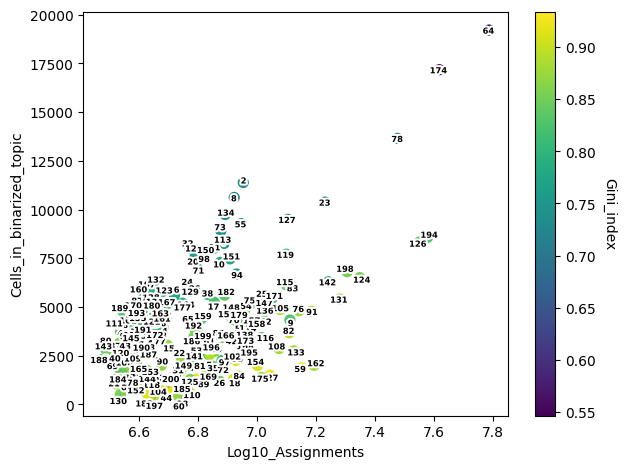

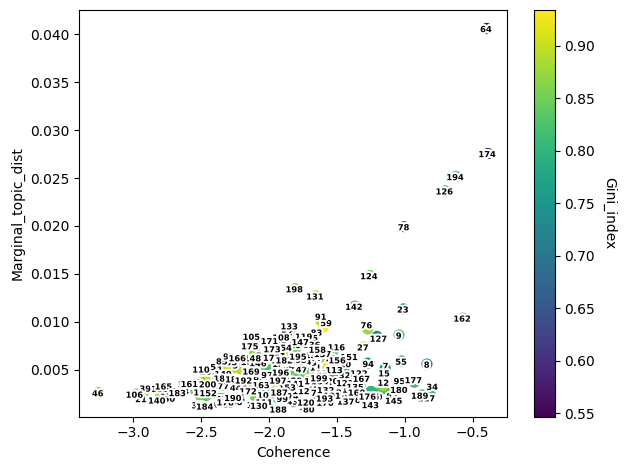

In [11]:
#AssignmentsVSCells_in_bin
plot_topic_qc(topic_qc_metrics, var_x='Log10_Assignments', var_y='Cells_in_binarized_topic', var_color='Gini_index',
    dot_size=50,
    text_size=6,
    plot=True,
    save="./plots/AssignmentsVSCells_in_bin_200topics_Group_v4_geosketch_50kcells_neuron.pdf" )

#CoherenceVSMarginal_dist
plot_topic_qc(topic_qc_metrics, var_x='Coherence', var_y='Marginal_topic_dist', var_color='Gini_index',
    dot_size=50,
    text_size=6,
    plot=True,
    save="./plots/CoherenceVSMarginal_dist_200topics_Group_v4_geosketch_50kcells_neuron.pdf" )

In [12]:
topic_annot = topic_annotation(
    cistopic_obj,
    annot_var='Subcortex_Group_v4',
    binarized_cell_topic=binarized_cell_topic,
    general_topic_thr = 0.2
)
topic_annot

,Subcortex_Group_v4,Ratio_cells_in_topic,Ratio_group_in_population,is_general
Topic1,,0.053454,0.0,False
Topic2,,0.239072,0.0,True
Topic3,,0.028574,0.0,False
Topic4,,0.0827,0.0,False
Topic5,,0.042431,0.0,False
...,...,...,...,...
Topic196,,0.053727,0.0,False
Topic197,,0.010204,0.0,False
Topic198,,0.142935,0.0,False
Topic199,,0.073672,0.0,False


In [13]:
# Save cistopicsobject with model and topic binarization
out_cistopic_path = "/jukebox/krienen/victor/marm_hmba_atac_downsampled/data/cistopic_obj_geosketch_50kcells_marm_subcortex_neuron.pkl"
with open(out_cistopic_path, "wb") as fh:
    pickle.dump(cistopic_obj, fh)
